02) CURVAS DE KAPLAN-MEIER
- El objetivo de esta sección es estimar y comparar la supervivencia de los pacientes en función de su estadio TNM, sexo y grupo de edad
- Esto lo realizaré mediante curvas de Kaplan-Meier y tests log-rank

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import os

#Cargo el CSV limpio generado en 01_eda.ipynb
luad = pd.read_csv("../data/tcga_luad_modelo.csv")
print(f"Pacientes cargados: {len(luad)}")
luad.head()

Pacientes cargados: 509


,tiempo_anios,evento,estadio,age_at_index,grupo_edad,sexo,ajcc_pathologic_n,ajcc_pathologic_m,primary_diagnosis
0,2.836413,0,I,60.0,55-65,Mujer,N0,M0,"Adenocarcinoma, NOS"
1,1.993155,0,NaN,64.0,55-65,Hombre,NaN,NaN,Mucinous adenocarcinoma
2,0.380561,1,III,65.0,65-75,Mujer,N2,M0,Adenocarcinoma with mixed subtypes
3,1.409993,0,I,87.0,>75,Mujer,N0,MX,"Adenocarcinoma, NOS"
4,2.264203,0,II,60.0,55-65,Hombre,N0,MX,"Squamous cell carcinoma, NOS"


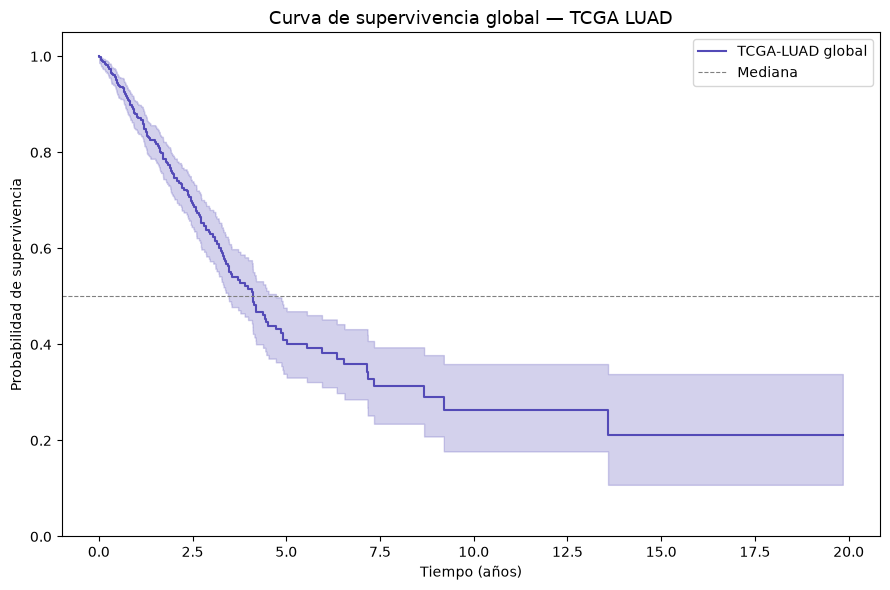

Mediana de supervivencia: 4.10 años


In [ ]:
#2.1. Curva global de supervivencia
kmf = KaplanMeierFitter()

#Ajusto el modelo a los datos, pasándole el tiempo de seguimiento de cada paciente
#y si el paciente murió o fue censurado
kmf.fit(
    durations=luad["tiempo_anios"],
    event_observed=luad["evento"],
    label="TCGA-LUAD global"
)

fig, ax = plt.subplots(figsize=(9, 6))

#Dibujo la curva de supervivencia, mostrando el intervalo de confianza al 95%
#con un sombreado alrededor de la curva. Esto indica la incertidumbre de la estimación
kmf.plot_survival_function(
    ax=ax,
    ci_show=True,
    color="#534AB7"
)
#Línea horizontal en y=0.5 (50% de supervivencia), porque donde esta línea cruce la curva, será la mediana
#Es decir, el tiempo en que la mitad de los pacientes ha fallecido.
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Mediana")
ax.set_title("Curva de supervivencia global — TCGA LUAD", fontsize=13)
ax.set_xlabel("Tiempo (años)")
ax.set_ylabel("Probabilidad de supervivencia")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()

#guardo la imagen en la carpeta "figures" del proyecto
plt.savefig("../figures/km_global.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mediana de supervivencia: {kmf.median_survival_time_:.2f} años")

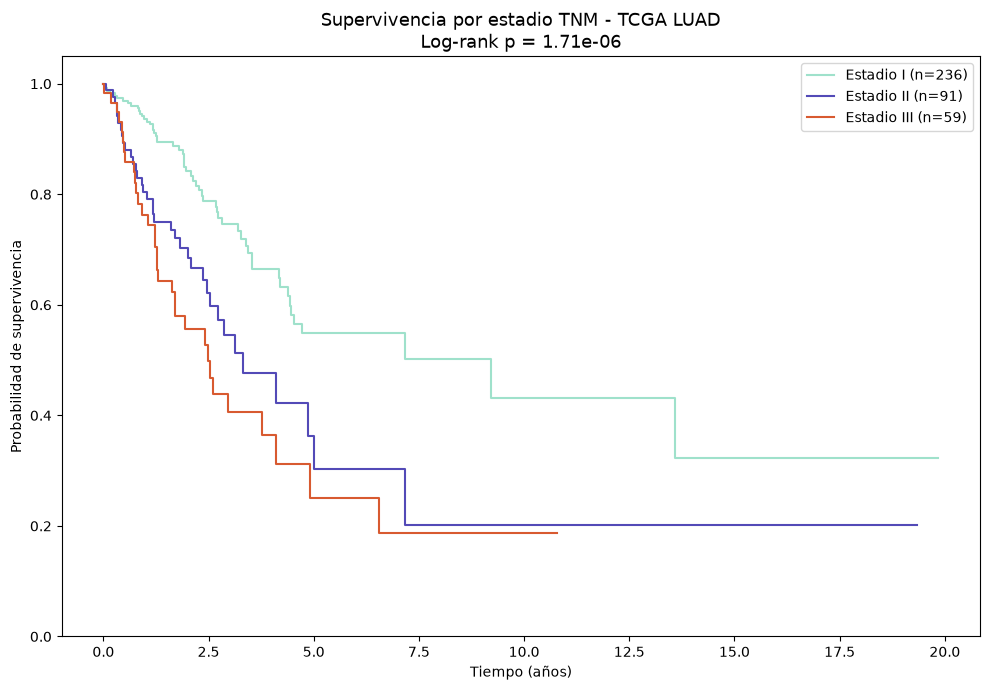

In [2]:
#2.2 Curva por estadio TNM
luad_estadio = luad.dropna(subset=["estadio"])

colores_estadio = {
    "I": "#9FE1CB",
    "II": "#534AB7",
    "III": "#D85A30",
    "IV": "#2C2C2A"
}
fig, ax = plt.subplots(figsize=(10,7))

for estadio_val in ["I", "II", "III", "IV"]:
    mask = luad_estadio["estadio"] == estadio_val
    subset = luad_estadio[mask]
    if len(subset) == 0:
        continue

    kmf_e = KaplanMeierFitter()
    kmf_e.fit(
        durations=subset["tiempo_anios"],
        event_observed=subset["evento"],
        label=f"Estadio {estadio_val} (n={mask.sum()})"
    )
    kmf_e.plot_survival_function(
        ax=ax,
        ci_show=False,
        color=colores_estadio[estadio_val]
    )

#Ahora ejecuto un test log-rank multivariante
resultado_lr = multivariate_logrank_test(
    luad_estadio["tiempo_anios"],
    luad_estadio["estadio"],
    luad_estadio["evento"]
)

ax.set_title(
    f"Supervivencia por estadio TNM - TCGA LUAD\n"
    f"Log-rank p = {resultado_lr.p_value:.2e}",
    fontsize=13
)

ax.set_xlabel("Tiempo (años)")
ax.set_ylabel("Probabilidad de supervivencia")
ax.set_ylim(0,1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../figures/km_estadio.png", dpi=150, bbox_inches="tight")
plt.show()

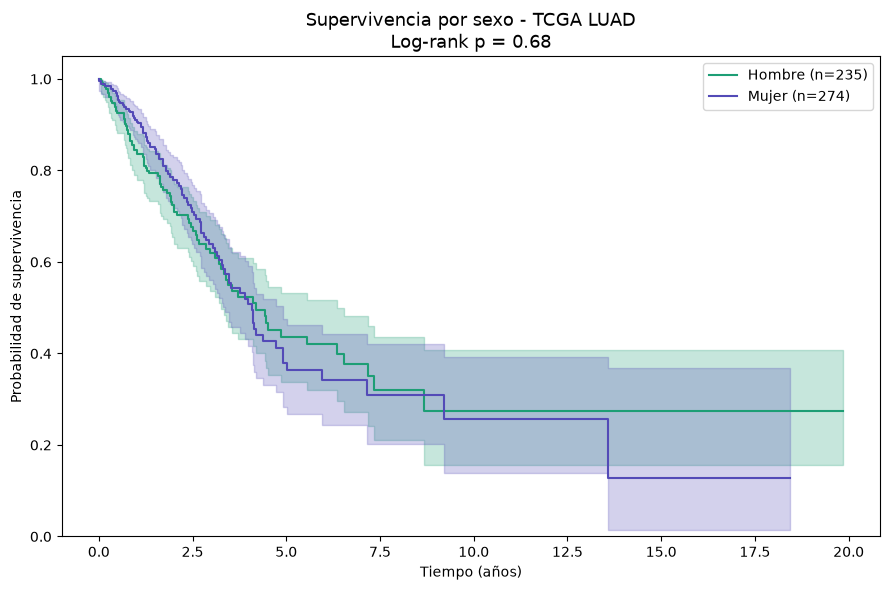

In [3]:
#2.3 Curva por sexo
fig, ax = plt.subplots(figsize=(9,6))
colores_sexo = {"Hombre": "#1D9E75", "Mujer": "#534AB7"}

for sexo_val in ["Hombre", "Mujer"]:
    mask = luad["sexo"] == sexo_val
    subset = luad[mask]
    kmf_s = KaplanMeierFitter()

    kmf_s.fit(
        durations=subset["tiempo_anios"],
        event_observed=subset["evento"],
        label=f"{sexo_val} (n={mask.sum()})"
    )
    kmf_s.plot_survival_function(ax=ax, ci_show=True, color=colores_sexo[sexo_val])

#Test log-rank
mujer = luad[luad["sexo"] == "Mujer"]
hombre = luad[luad["sexo"] == "Hombre"]
lr_sexo = logrank_test(
    mujer["tiempo_anios"],  hombre["tiempo_anios"],
    mujer["evento"],        hombre["evento"]
)

ax.set_title(
    f"Supervivencia por sexo - TCGA LUAD\n"
    f"Log-rank p = {lr_sexo.p_value:.2f}",
    fontsize=13
)
ax.set_xlabel("Tiempo (años)")
ax.set_ylabel("Probabilidad de supervivencia")
ax.set_ylim(0,1.05)
ax.legend()
plt.tight_layout()
plt.savefig("../figures/km_sexo.png", dpi=150, bbox_inches="tight")
plt.show()

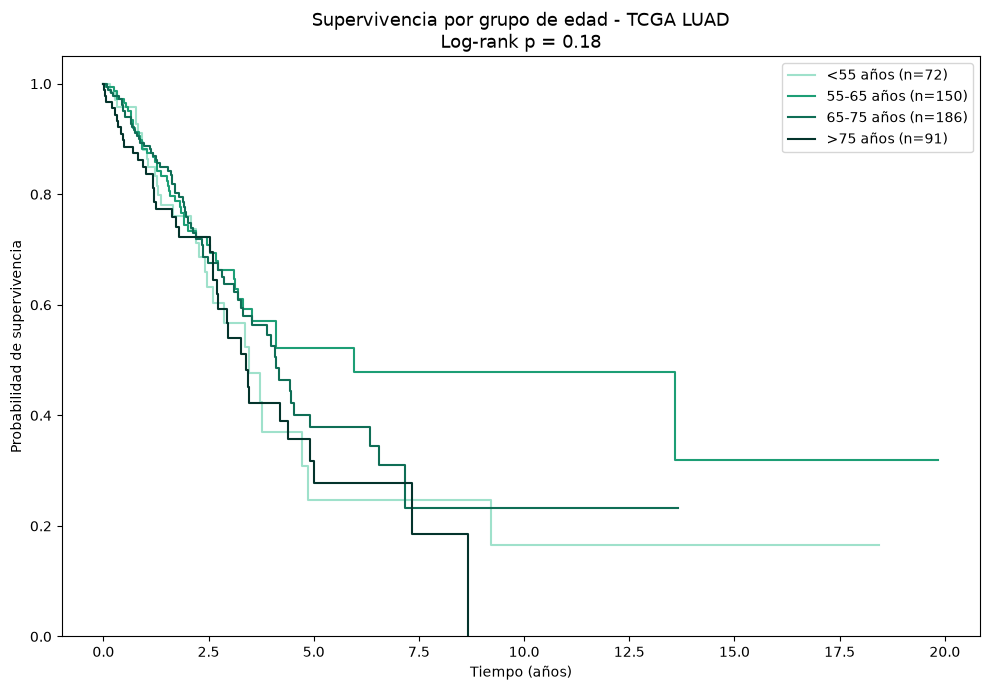

In [4]:
#2.4 Curva por grupo de edad
luad_edad = luad.dropna(subset=["grupo_edad"])

colores_edad = {
    "<55": "#9FE1CB",
    "55-65": "#1D9E75",
    "65-75": "#0F6E56",
    ">75": "#04342C"
}
fig, ax = plt.subplots(figsize=(10,7))

for grupo in ["<55", "55-65", "65-75", ">75"]:
    mask = luad_edad["grupo_edad"] == grupo
    subset = luad_edad[mask]
    if len(subset) == 0:
        continue
    kmf_a = KaplanMeierFitter()
    kmf_a.fit(
        durations=subset["tiempo_anios"],
        event_observed=subset["evento"],
        label=f"{grupo} años (n={mask.sum()})"
    )
    kmf_a.plot_survival_function(ax=ax, ci_show=False, color=colores_edad[grupo])

#Test log-rank
lr_edad = multivariate_logrank_test(
    luad_edad["tiempo_anios"],
    luad_edad["grupo_edad"],
    luad_edad["evento"]
)

ax.set_title(
    f"Supervivencia por grupo de edad - TCGA LUAD\n"
    f"Log-rank p = {lr_edad.p_value:.2f}",
    fontsize=13
)
ax.set_xlabel("Tiempo (años)")
ax.set_ylabel("Probabilidad de supervivencia")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../figures/km_edad.png", dpi=150, bbox_inches="tight")
plt.show()